# Task 5: Outlier Detection and Treatment
**Data Science in Cybersecurity – Practical Assignment**

This notebook identifies anomalous values in numerical features and applies suitable treatment methods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load output from Task 4
# NOTE: We work on the PRE-SCALED version (task3 output) for interpretable outlier bounds
df = pd.read_csv('cybersecurity_task3.csv')

# Re-apply categorical standardization from Task 4
df['protocol'] = df['protocol'].str.strip().str.upper()
df['flag']     = df['flag'].str.strip().str.upper()
df['label']    = df['label'].str.strip().str.upper()

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (437, 17)


,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,pkt_size_avg,fwd_iat_mean,bwd_iat_mean,flow_bytes/s,flow_pkts/s,flag,label
0,flow_0000,7.140.125.58,99999,171.84.26.102,22,TCP,2024-01-03 10:47:07,NaN,212.0,140.0,527.75,2154.51,2757.13,819791.08,103.97,ACK,PORTSCAN
1,flow_0001,27.44.216.9,51191,161.156.119.110,8080,TCP,2024-01-19 14:55:33,NaN,-5.0,NaN,374.60,3870.88,1352.54,424592.44,708.53,SYN,BENIGN
2,flow_0003,130.13.101.184,99999,55.244.39.34,22,HTTP,2024-01-20 00:36:58,-999.0,NaN,264.0,1463.45,374.99,3251.68,740429.12,518.97,FIN,DDOS
3,flow_0004,140.214.112.115,51228,152.115.227.3,21,UDP,01-29-2024 22:31:54,9999999.0,NaN,452.0,1213.28,3138.95,1517.09,221694.04,382.59,FIN,BENIGN
4,flow_0005,208.3.81.179,16796,3.175.61.253,8080,TCP,01-22-2024 15:26:12,44392.0,300.0,NaN,99999.90,4023.63,4857.33,767843.93,590.34,SYN,BRUTE FORCE


## 5.1 – Select Numerical Features

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude port columns (treated as categorical/identifiers)
feature_cols = [c for c in numeric_cols if c not in ['src_port', 'dst_port']]
print('Numerical features for outlier analysis:')
print(feature_cols)

Numerical features for outlier analysis:
['flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'pkt_size_avg', 'fwd_iat_mean', 'bwd_iat_mean', 'flow_bytes/s', 'flow_pkts/s']


## 5.2 – Visual Inspection with Boxplots

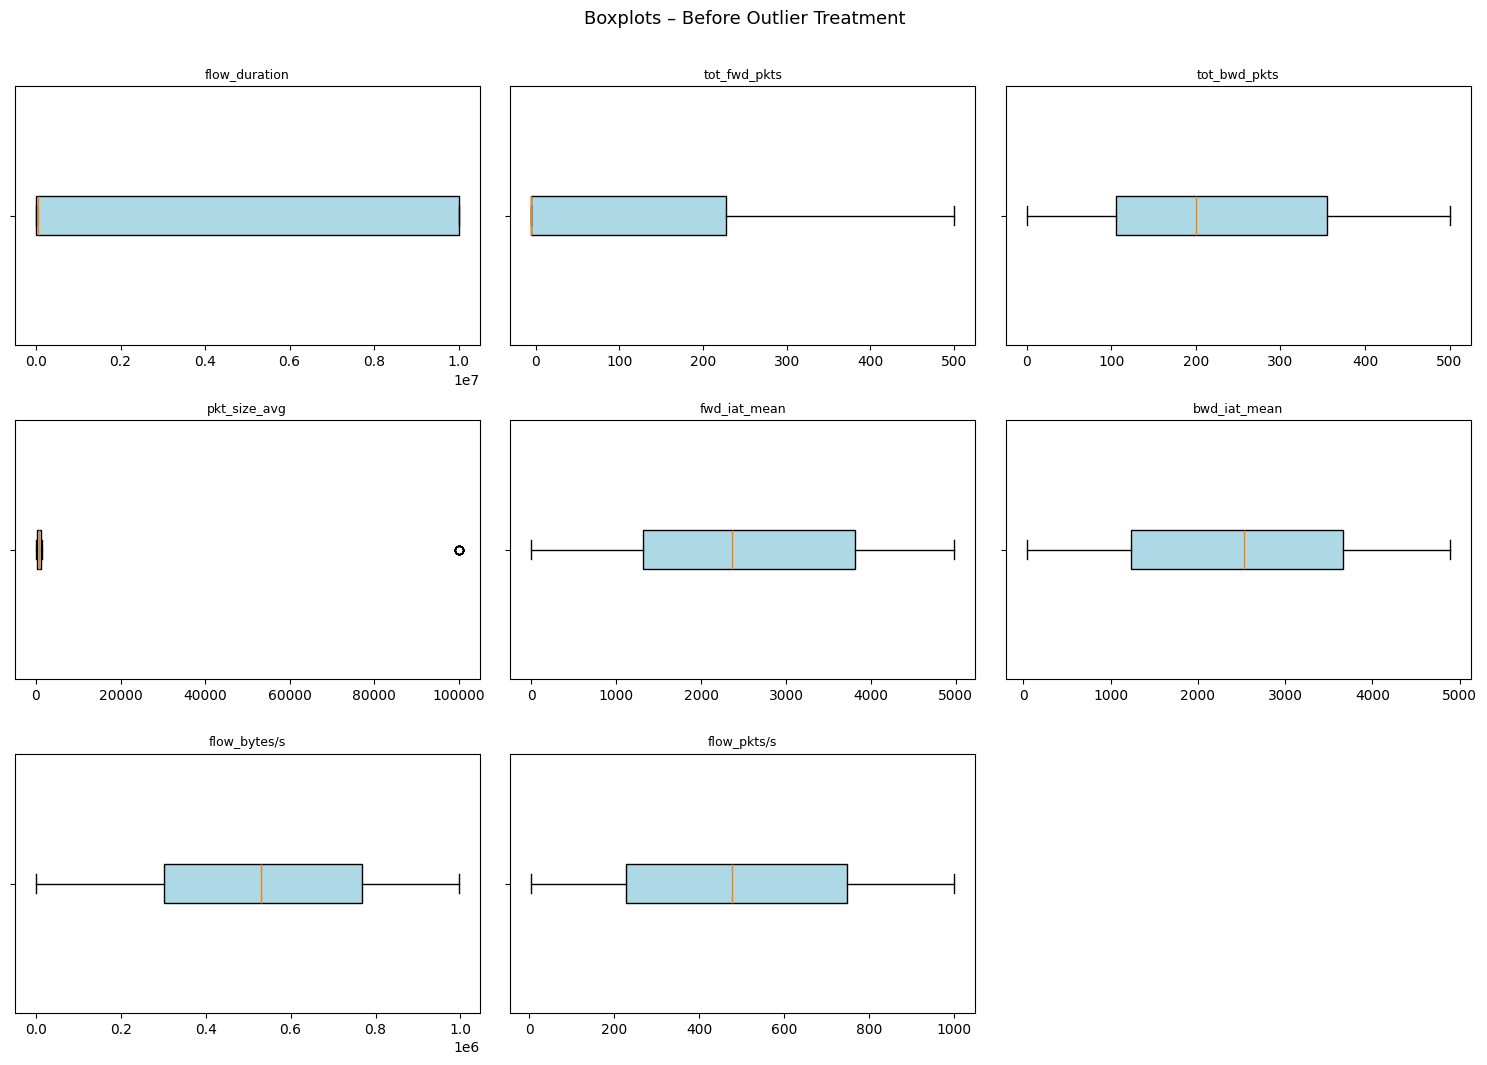

In [3]:
n = len(feature_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticklabels([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots – Before Outlier Treatment', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task5_boxplots_before.png', dpi=150)
plt.show()

## 5.3 – IQR-Based Outlier Detection

The **Interquartile Range (IQR)** method defines outliers as values outside:

$$\text{Lower fence} = Q_1 - 1.5 \times IQR \qquad \text{Upper fence} = Q_3 + 1.5 \times IQR$$

In [4]:
def iqr_outlier_summary(series):
    """Return IQR fences and outlier count for a Series."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                      'lower_fence': lower, 'upper_fence': upper,
                      'n_outliers': n_outliers,
                      'pct_outliers': round(n_outliers / len(series) * 100, 2)})

iqr_summary = df[feature_cols].apply(iqr_outlier_summary).T
print('IQR Outlier Summary:')
print(iqr_summary.to_string())

IQR Outlier Summary:
                       Q1           Q3           IQR   lower_fence   upper_fence  n_outliers  pct_outliers
flow_duration    -999.000  9999999.000  1.000100e+07 -1.500250e+07  2.500150e+07         0.0          0.00
tot_fwd_pkts       -5.000      227.500  2.325000e+02 -3.537500e+02  5.762500e+02         0.0          0.00
tot_bwd_pkts      105.500      355.500  2.500000e+02 -2.695000e+02  7.305000e+02         0.0          0.00
pkt_size_avg      319.440     1134.290  8.148500e+02 -9.028350e+02  2.356565e+03        10.0          2.29
fwd_iat_mean     1314.140     3813.040  2.498900e+03 -2.434210e+03  7.561390e+03         0.0          0.00
bwd_iat_mean     1231.160     3664.300  2.433140e+03 -2.418550e+03  7.314010e+03         0.0          0.00
flow_bytes/s   301934.500   767446.265  4.655118e+05 -3.963331e+05  1.465714e+06         0.0          0.00
flow_pkts/s       226.815      746.425  5.196100e+02 -5.526000e+02  1.525840e+03         0.0          0.00


## 5.4 – Z-Score Based Outlier Detection (threshold = 3)

In [5]:
from scipy import stats

z_scores = df[feature_cols].apply(lambda x: np.abs(stats.zscore(x.dropna())))
zscore_outlier_counts = (df[feature_cols].apply(
    lambda x: (np.abs((x - x.mean()) / x.std()) > 3).sum()
))
print('Z-Score Outlier Counts (|z| > 3):')
print(zscore_outlier_counts.to_string())

Z-Score Outlier Counts (|z| > 3):
flow_duration     0
tot_fwd_pkts      0
tot_bwd_pkts      0
pkt_size_avg     10
fwd_iat_mean      0
bwd_iat_mean      0
flow_bytes/s      0
flow_pkts/s       0


## 5.5 – Outlier Treatment: Winsorization (Capping)

We **cap** (Winsorize) outliers at the IQR fences instead of dropping them.  
This preserves row count while eliminating extreme values — important when attack records may appear extreme by design.

In [6]:
df_treated = df.copy()

for col in feature_cols:
    Q1    = df_treated[col].quantile(0.25)
    Q3    = df_treated[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_treated[col] < lower) | (df_treated[col] > upper)).sum()
    df_treated[col] = df_treated[col].clip(lower=lower, upper=upper)
    print(f'  [{col}]  capped {before} outliers  →  [{lower:.3f}, {upper:.3f}]')

  [flow_duration]  capped 0 outliers  →  [-15002496.000, 25001496.000]
  [tot_fwd_pkts]  capped 0 outliers  →  [-353.750, 576.250]
  [tot_bwd_pkts]  capped 0 outliers  →  [-269.500, 730.500]
  [pkt_size_avg]  capped 10 outliers  →  [-902.835, 2356.565]
  [fwd_iat_mean]  capped 0 outliers  →  [-2434.210, 7561.390]
  [bwd_iat_mean]  capped 0 outliers  →  [-2418.550, 7314.010]
  [flow_bytes/s]  capped 0 outliers  →  [-396333.147, 1465713.913]
  [flow_pkts/s]  capped 0 outliers  →  [-552.600, 1525.840]


## 5.6 – Visual Comparison: Before vs After

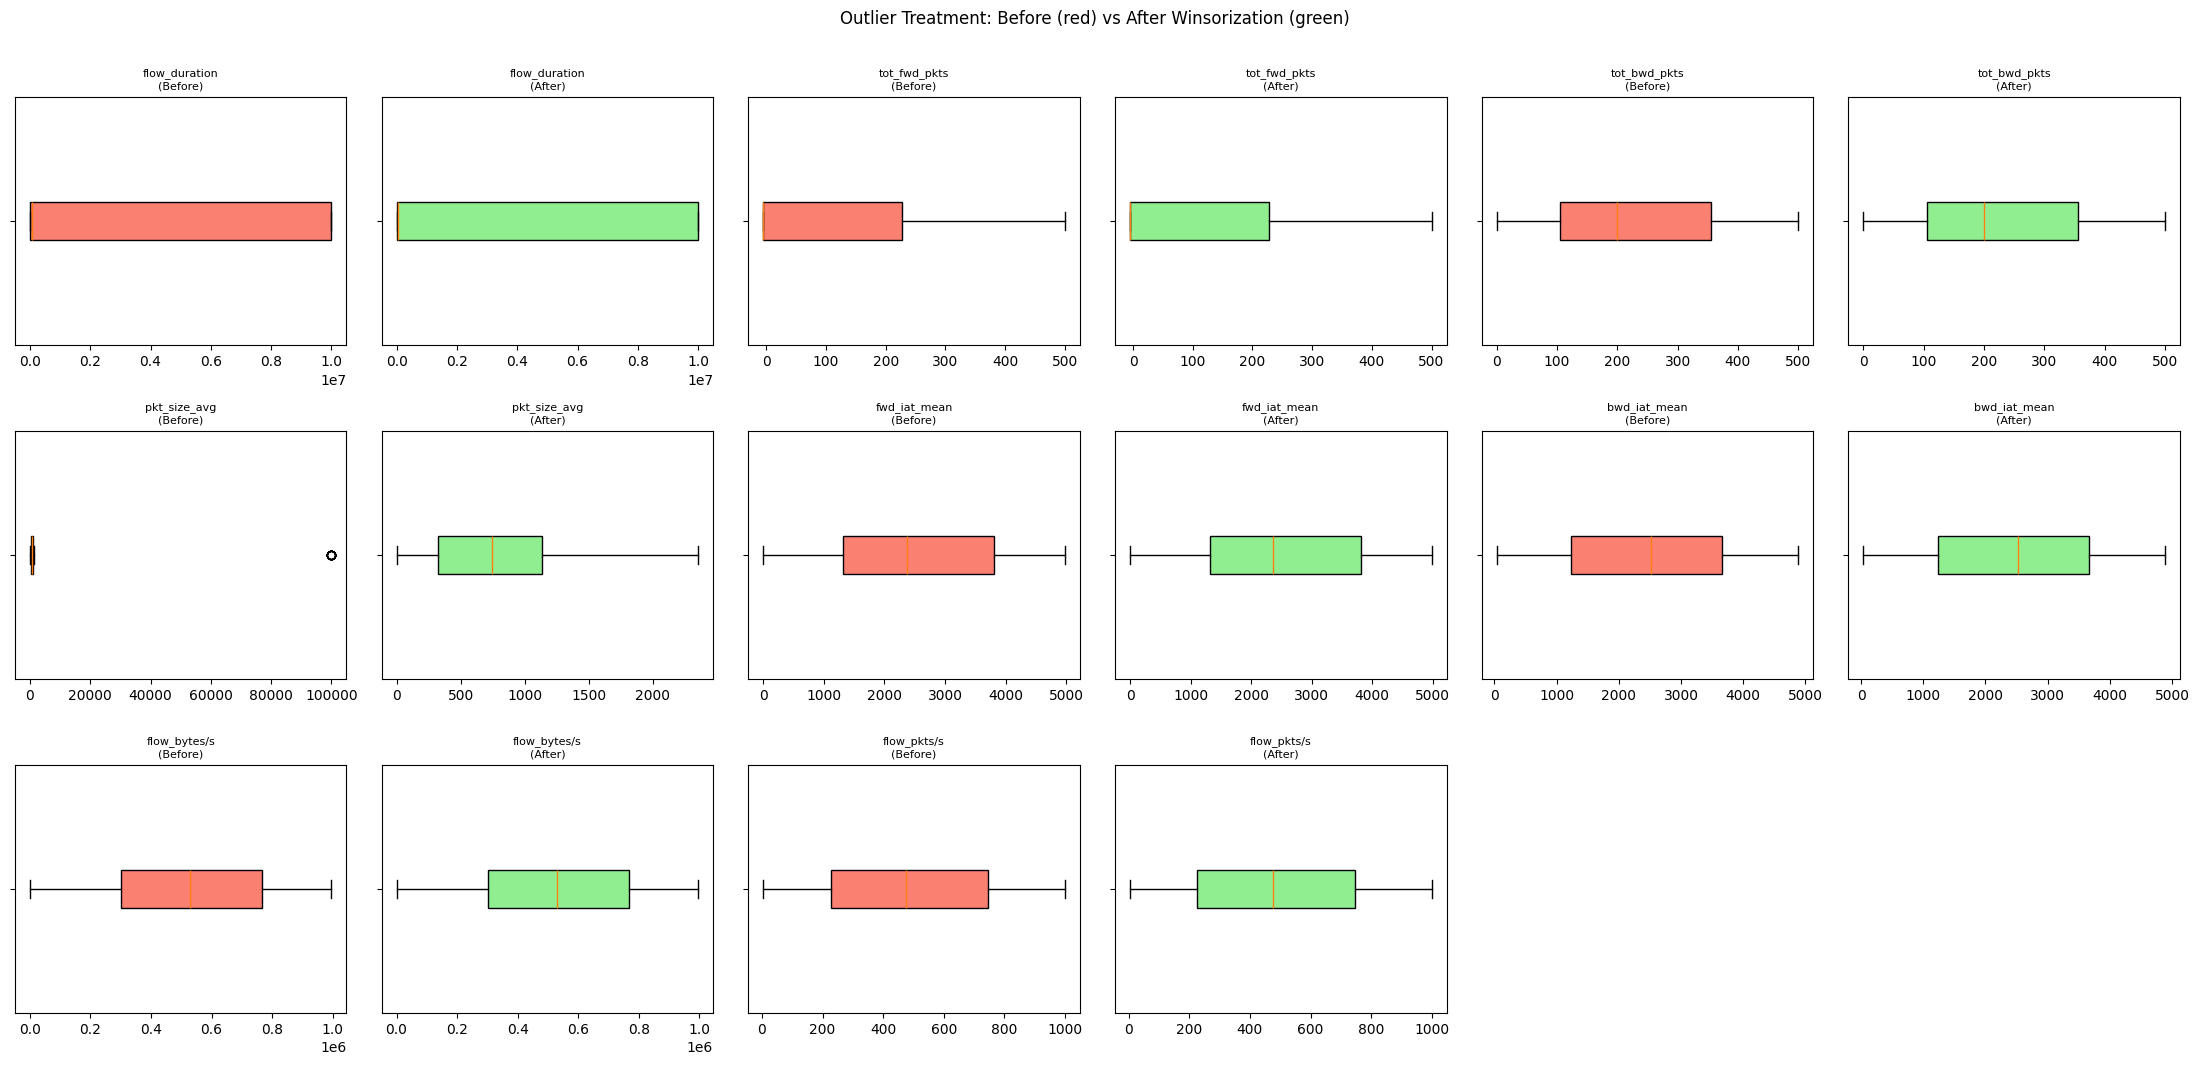

In [7]:
fig, axes = plt.subplots(nrows, ncols * 2, figsize=(22, nrows * 3.5))

for i, col in enumerate(feature_cols):
    row = i // ncols
    col_offset = (i % ncols) * 2

    axes[row][col_offset].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                                   boxprops=dict(facecolor='salmon'))
    axes[row][col_offset].set_title(f'{col}\n(Before)', fontsize=8)
    axes[row][col_offset].set_yticklabels([])

    axes[row][col_offset + 1].boxplot(df_treated[col].dropna(), vert=False,
                                       patch_artist=True,
                                       boxprops=dict(facecolor='lightgreen'))
    axes[row][col_offset + 1].set_title(f'{col}\n(After)', fontsize=8)
    axes[row][col_offset + 1].set_yticklabels([])

# Hide unused axes
for j in range(n, nrows * ncols):
    row = j // ncols
    col_offset = (j % ncols) * 2
    try:
        axes[row][col_offset].set_visible(False)
        axes[row][col_offset + 1].set_visible(False)
    except IndexError:
        pass

plt.suptitle('Outlier Treatment: Before (red) vs After Winsorization (green)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('task5_outlier_treatment_comparison.png', dpi=150)
plt.show()

## 5.7 – Save for Next Task

In [8]:
df_treated.to_csv('cybersecurity_task5.csv', index=False)
print(f'Outlier-treated dataset saved to cybersecurity_task5.csv  |  shape: {df_treated.shape}')

Outlier-treated dataset saved to cybersecurity_task5.csv  |  shape: (437, 17)
